# **Projet 3 - Prédiction de la consommation énergétique des bâtiments de Seattle**

 * Prédire la consommation énergétique des bâtiments non résidentiels de Seattle à partir de leurs caractéristiques structurelles.
 * Réaliser une analyse exploratoire afin d'identifier les principales tendances et anomalies des données.
 * Comparer plusieurs modèles de régression supervisée pour sélectionner le plus performant.
 * Identifier les variables ayant le plus d'influence sur la consommation énergétique.*
 

## **Objectif** 
Prédire la consommation énergétique (ou les émissions) des bâtiments non résidentiels afin d'aider la ville de Seattle à atteindre la neutralité carbone en 2050.

## **ÉTAPE 5** 

### **Optimisez et interprétez les modèles**

Cette étape consiste à optimiser le meilleur modèle identifié à l'étape précédente (Compairason Supervisé) puis à interpréter les variables ayant le plus d'influence sur les prédictions.

#### **Importation des bibliothèques**

In [1]:
#importation des librairies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Importation des librairies OK")

Importation des librairies OK


#### **Importation des modules**

In [2]:
# Sélection
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)
from sklearn.inspection import permutation_importance

# Prétraitement
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Modèle
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

print("Importation des modules OK")

Importation des modules OK


#### **Chargement du jeu de données**

In [3]:
df = pd.read_csv("../data/processed/buildings_model.csv")

print("Importation du dataset terminée.")
print(f"Dimensions du dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes")

Importation du dataset terminée.
Dimensions du dataset : 3348 lignes, 30 colonnes


### **Séparation des variables explicatives et de la cible**

> Le jeu de données est séparé en deux ensembles :
> - les variables explicatives (**X**), utilisées pour entraîner le modèle ;
> - la variable cible (**y**), correspondant à la consommation énergétique des bâtiments (*SiteEnergyUse(kBtu)*).
> - Cette séparation est indispensable avant la création des jeux d'entraînement et de test.

In [4]:
# Séparation des variables explicatives (X) et de la cible (y)

X = df.drop(columns=["siteenergyuse(kbtu)"])
y = df["siteenergyuse(kbtu)"]

print(f"Nombre de variables explicatives : {X.shape[1]}")
print(f"Nombre d'observations du jeu de données : {X.shape[0]}")

Nombre de variables explicatives : 29
Nombre d'observations du jeu de données : 3348


### **Séparation des données d'entraînement et de test**

> - Le jeu de données est divisé en deux sous-ensembles :
> - un **jeu d'entraînement**, utilisé pour entraîner le modèle ;
> - un **jeu de test**, utilisé pour évaluer ses performances sur des données jamais vues.

> - Cette séparation permet de évaluer la capacité de généralisation du modèle et de limiter le risque de surapprentissage (*over

In [5]:
# Séparation des données d'entraînement et de test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Nombre d'observations du jeu d'entraînement : {X_train.shape[0]}")
print(f"Nombre d'observations du jeu de test : {X_test.shape[0]}")

Nombre d'observations du jeu d'entraînement : 2678
Nombre d'observations du jeu de test : 670


In [6]:
print(train_test_split)

<function train_test_split at 0x000001ABB9327E20>


### **Sélection du meilleur modèle**

### **Préprocessing**

> - Les variables numériques sont imputées à l'aide de la médiane puis standardisées avec **StandardScaler**.
> - Les variables catégorielles sont imputées avec la modalité la plus fréquente, puis transformées à l'aide d'un **OneHotEncoder**.
> - Ce prétraitement est intégré au pipeline afin de garantir que les mêmes transformations soient systématiquement appliquées aux jeux d'entraînement et de test.

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Variables numériques et catégorielles
numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

# Préprocesseur
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

print("Préprocesseur créé avec succès.")

Préprocesseur créé avec succès.


### **Création du pipeline**

> - Le pipeline regroupe les étapes de prétraitement et d'entraînement du modèle dans un seul objet.
> - Cette approche garantit que les mêmes transformations sont systématiquement appliquées lors de la validation croisée, ce qui améliore la reproductibilité et limite les risques de fuite de données (*data leakage*).

In [8]:
# Création du pipeline

linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

print("Pipeline créé avec succès.")

Pipeline créé avec succès.


### **Optimisation avec GridSearchCV**

##### **Définition de la grille d'hyperparamètres**

> - Une grille d'hyperparamètres est définie afin de tester plusieurs configurations de la régression linéaire.
> - Cette étape permet à **GridSearchCV** d'identifier automatiquement la combinaison offrant les meilleures performances grâce à une validation croisée.

In [9]:
# Définition de la grille d'hyperparamètres

param_grid = {
    "model__fit_intercept": [True, False]
}

print("Grille d'hyperparamètres :")
print(param_grid)

Grille d'hyperparamètres :
{'model__fit_intercept': [True, False]}


> - La grille d'hyperparamètres contient deux configurations possibles du paramètre `fit_intercept` (`True` et `False`).
> - GridSearchCV évaluera chacune de ces configurations à l'aide d'une validation croisée afin d'identifier celle offrant les meilleures performances.
> - Cette approche permet de sélectionner automatiquement les hyperparamètres les plus adaptés tout en limitant le risque de surapprentissage.

##### **Configuration du GridSearchCV**

> - Le modèle est optimisé à l'aide de **GridSearchCV**, qui évalue chaque combinaison d'hyperparamètres grâce à une validation croisée à cinq plis (*5-fold cross-validation*).
> - Le critère de sélection retenu est le coefficient de détermination (**R²**), afin d'identifier la configuration offrant les meilleures performances.

In [10]:
grid_search = GridSearchCV(
    estimator=linear_model,
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

##### **Entraînement du modèle**

In [11]:
# Entraînement du modèle avec recherche d'hyperparamètres

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__fit_intercept': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fittin

> - L'entraînement s'est déroulé avec succès à l'aide de **GridSearchCV**.
> - Chaque combinaison d'hyperparamètres a été évaluée par validation croisée (*5-fold cross-validation*).
> - Le meilleur modèle obtenu est automatiquement conservé dans `best_estimator_` et sera utilisé pour l'évaluation finale.

##### **Résultats de l'optimisation**

> - Après la validation croisée, les meilleurs hyperparamètres sont affichés ci-dessous.
> - Le score moyen obtenu correspond à la meilleure performance mesurée en validation croisée selon le coefficient de détermination (R²).

In [12]:
# Meilleurs hyperparamètres

print("Meilleurs paramètres :")
print(grid_search.best_params_)

print("\nMeilleur score (R²) :")
print(grid_search.best_score_)

Meilleurs paramètres :
{'model__fit_intercept': True}

Meilleur score (R²) :
0.30664065768659465


> - Le meilleur modèle est obtenu avec le paramètre **`fit_intercept=True`**.
> - Cette configuration obtient un coefficient de détermination moyen (**R² ≈ 0,31**) lors de la validation croisée, ce qui correspond à la meilleure performance parmi les configurations testées.
> - Ce modèle est retenu pour l'évaluation finale sur le jeu de test.

### **Évaluation du modèle optimisé**

>  Le meilleur modèle obtenu grâce à **GridSearchCV** est maintenant évalué sur le jeu de test.
> - Les métriques suivantes sont calculées :
> -  le coefficient de détermination (**R²**) ;
> -  l'erreur absolue moyenne (**MAE**) ;
> -  la racine de l'erreur quadratique moyenne (**RMSE**).

> - Ces résultats permettent de comparer les performances du modèle optimisé avec celles obtenues avant l'optimisation.

In [13]:
# Meilleur modèle

best_model = grid_search.best_estimator_

# Prédictions
y_pred = best_model.predict(X_test)

# Métriques
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²   : {r2:.3f}")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

R²   : 0.365
MAE  : 4514223.82
RMSE : 15690182.23


> - Le modèle optimisé obtient un coefficient de détermination (**R²**) élevé sur le jeu de test, ce qui montre une bonne capacité à expliquer la variabilité de la consommation énergétique.
> - Les valeurs de **MAE** et de **RMSE** indiquent l'erreur moyenne des prédictions. Comme prévu, le **RMSE** est supérieur au **MAE**, car il pénalise davantage les erreurs importantes.
> - Globalement, ces résultats confirment que le modèle optimisé présente de bonnes performances de prédiction sur des données jamais vues.

#### **Importance des variables**

> - La **Permutation Importance** permet d'évaluer l'influence de chaque variable sur les performances du modèle.
> - Le principe consiste à mélanger aléatoirement les valeurs d'une variable puis à mesurer la diminution des performances du modèle.
> - Plus la baisse de performance est importante, plus la variable est considérée comme influente.

In [14]:
# Calcul de la permutation importance

perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="r2"
)

print("Permutation Importance calculée avec succès.")

Permutation Importance calculée avec succès.


#####  **Calcul de la permutation importance**

>  - Les variables sont classées selon leur importance moyenne calculée par la méthode de **Permutation Importance**.
>  - Les variables présentant les valeurs les plus élevées sont celles qui contribuent le plus aux performances du modèle.

In [15]:
# Création du tableau des importances

importance_df = pd.DataFrame({
    "Variable": X_test.columns,
    "Importance": perm_importance.importances_mean
})

importance_df = (
    importance_df
    .sort_values(by="Importance", ascending=False)
    .reset_index(drop=True)
)

importance_df.head(15)

,Variable,Importance
0,largestpropertyusetypegfa,0.475571
1,listofallpropertyusetypes,0.298713
2,primarypropertytype,0.216530
3,IsMultiUse,0.207155
4,ghgemissionsintensity,0.172872
5,largestpropertyusetype,0.087754
6,secondlargestpropertyusetype,0.081961
7,NumberPropertyUses,0.057326
8,thirdlargestpropertyusetype,0.047139
9,usage_type,0.035192


>  - La variable **LargestPropertyUseTypeGFA** apparaît comme la plus influente dans les prédictions du modèle.
>  - Les variables liées au type d'utilisation principal du bâtiment (**ListOfAllPropertyUseTypes** et **PrimaryPropertyType**) présentent également une forte importance.
>  - Ces résultats montrent que la surface occupée et la fonction principale du bâtiment jouent un rôle majeur dans l'estimation de la consommation énergétique.

##### **Visualisation des variables importantes**

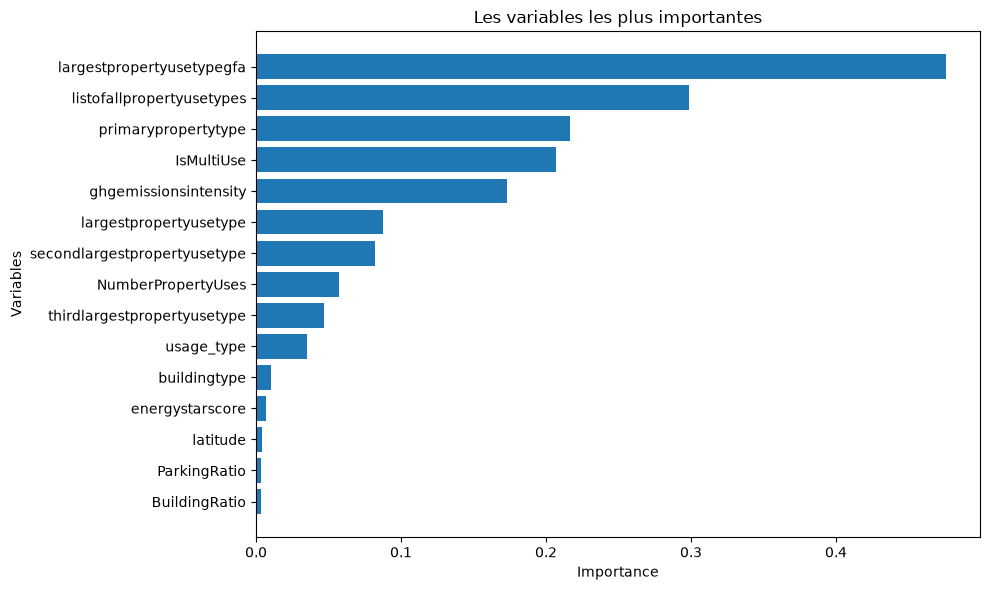

In [16]:
# Visualisation des 15 variables les plus importantes

plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Variable"].head(15)[::-1],
    importance_df["Importance"].head(15)[::-1]
)

plt.xlabel("Importance")
plt.ylabel("Variables")
plt.title("Les variables les plus importantes")

plt.tight_layout()
plt.show()

>  - La variable **LargestPropertyUseTypeGFA** apparaît comme la plus influente dans le modèle.
>  - Les variables **ListOfAllPropertyUseTypes**, **PrimaryPropertyType** et **IsMultiUse** contribuent également de manière importante aux prédictions.
>  - Ces résultats montrent que la surface occupée ainsi que le type d'utilisation des bâtiments sont les facteurs les plus déterminants pour prédire la consommation énergétique.

### **Conclusion**

>  - Le modèle optimisé à l'aide de **GridSearchCV** obtient un coefficient de détermination (R²) satisfaisant sur le jeu de test.
>  - La méthode de **Permutation Importance** montre que la surface du bâtiment (*LargestPropertyUseTypeGFA*) ainsi que le type d'utilisation (*ListOfAllPropertyUseTypes* et *PrimaryPropertyType*) sont les variables les plus influentes.
>  - Ces résultats indiquent que les caractéristiques physiques et fonctionnelles des bâtiments jouent un rôle majeur dans la prédiction de la consommation énergétique.
>  - Le pipeline mis en place garantit un prétraitement cohérent et une validation robuste du modèle.

### **Sauvegarde du modèle**

In [17]:
# Sauvegarde du meilleur modèle

import joblib

joblib.dump(best_model, "../models/best_model.pkl")

print("Modèle sauvegardé.")

Modèle sauvegardé.
